## 1. Test loading of all the packages first

In [1]:
"""
Complete CD133 E14 vs E18 Pipeline Test
With Repository, Builder, and Strategy Patterns

This tests all the refactored code including the new Strategy pattern.
"""

import os
import pandas as pd
import numpy as np
import sys

# Set up path
# get project root (two levels up from this notebook)
project_root = os.path.abspath(os.path.join(os.path.dirname('src'), '..'))
# if in notebook:
# project_root = os.path.abspath('..')   # or adjust as needed
if project_root not in sys.path:
    sys.path.insert(0, project_root)


In [2]:
from src.engine.builder import NSCAnalysisBuilder
from src.engine.pipeline import NSCAnalysis

In [3]:
import src.engine.pipeline as pipeline

In [4]:
from src.io.reg_region_integrator import (
    ConsensusPeakBuilder,
    EnhancerIntegrator,
    RegulatoryRegionMaker
)
from src.models.expr.differential_expression import (
    DifferentialExpressionContext,
    DESeq2Strategy,
    GJSDStrategy
)

## 2. Check if DeSeq 2 runs with the new builder/strategy design patterns

In [5]:

# ==============================================================================
# PATHS
# ==============================================================================

base_dir = "/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC"

paths = {
    # RNA-seq
    "counts": os.path.join(base_dir, "data/rna_seq/E14_ E18_LGE_cortex_seq_Counts.csv"),
    "metadata": os.path.join(base_dir, "data/rna_seq/Samples+Pooling_RNA-Seq.csv"),
    
    # ATAC-seq
    "atac_metadata": os.path.join(base_dir, "data/atac_seq/ATAC-seq/samples_all.csv"),
    "atac_peak_dir": os.path.join(base_dir, "data/atac_seq/ATAC-seq"),
    
    # Annotations
    "tf_list": os.path.join(base_dir, "data/annotations/Mouse_TFs_Kinases_webpage-3-30-2017.xlsx"),
    "gtf": os.path.join(base_dir, "data/annotations/gencode.vM36.annotation.gtf"),
    "enhancer_files": [
        os.path.join(base_dir, "data/annotations/enhancerAtlas_neuron_cortical.txt"),
        os.path.join(base_dir, "data/annotations/enhancerAtlas_brain_e14.5.txt"),
        os.path.join(base_dir, "data/annotations/enhancerAtlas_cortex.txt")
    ],
    
    # ChIP-seq
    "chip_peaks": os.path.join(base_dir, "data/chip_seq/Oth.Neu.05.AllAg.AllCell.bed"),
    
    # Integrated data
    "overlap_df": os.path.join(base_dir, "data/integrated/overlap_annotated.tsv"),
    "chip_annotated": os.path.join(base_dir, "data/integrated/chip_annotated_filtered.tsv"),
    "atac_annotated": os.path.join(base_dir, "data/integrated/atac_annotated.tsv"),
    
    # DA results
    "dar_all": os.path.join(base_dir, "results/diffbind_cd133/DAR_cd133_cortex_sig.csv"),
    
    # Output paths
    "output_dir": os.path.join(base_dir, "results/cd133_e14_e18_grn"),
    "consensus_bed": os.path.join(base_dir, "results/cd133_e14_e18_grn/consensus_cd133.bed"),
    "deseq_output": os.path.join(base_dir, "results/cd133_e14_e18_grn/deseq_temporal_cd133.csv"),
}

# Create output directory
os.makedirs(paths["output_dir"], exist_ok=True)

exclude_samples = ['MUC9939', 'MUC9940', 'MUC9914']

print("="*80)
print("CD133 E14 vs E18 GRN PIPELINE - WITH DESIGN PATTERNS")
print("="*80)

# ==============================================================================
# STEP 1: RNA-SEQ DIFFERENTIAL EXPRESSION (CD133 E14 vs E18)
# ==============================================================================

print("\n" + "="*80)
print("STEP 1: DIFFERENTIAL EXPRESSION ANALYSIS")
print("="*80)

# Option 1: Old way (still works - backward compatible)
print("\n[Method 1] Using old constructor (backward compatible)...")
nsc = NSCAnalysis(
    counts_path=paths['counts'],
    metadata_path=paths['metadata'],
    atac_metadata_path=paths['atac_metadata'],
    overlap_df_path=paths['overlap_df'],
    chip_annotated_path=paths['chip_annotated'],
    atac_annotated_path=paths['atac_annotated'],
    tf_list_path=paths['tf_list'],
    gtf_path=paths['gtf'],
    chip_peaks_path=paths['chip_peaks'],
    exclude_samples=exclude_samples
)

# Filter for CD133 samples only
cd133_samples = nsc.metadata[
    (nsc.metadata['Marker'] == 'Progenitors') & 
    (nsc.metadata['Region'] == 'Ctx')
].index.tolist()

nsc.counts = nsc.counts[[c for c in cd133_samples if c in nsc.counts.columns]]
nsc.metadata = nsc.metadata.loc[cd133_samples]

print(f"\nCD133 samples: {len(nsc.metadata)}")
print(nsc.metadata[['Stage', 'Region', 'Marker']].value_counts())

# Run DESeq2 (old way - still works)
print("\n[Old Method] Running DESeq2 directly...")
deseq_results = nsc.run_deseq(group1='E14', group2='E18', group_col='Stage')

# ===== NEW: Test Strategy Pattern =====
print("\n" + "="*80)
print("TESTING STRATEGY PATTERN")
print("="*80)

# Create DE context with DESeq2 strategy
print("\n[Strategy Pattern] Using DESeq2Strategy...")
de_context = DifferentialExpressionContext(strategy=DESeq2Strategy())
strategy_results = de_context.analyze(
    counts=nsc.counts,
    metadata=nsc.metadata,
    group1='E14',
    group2='E18',
    group_col='Stage'
)

# # Can easily switch strategies!
# print("\n[Strategy Pattern] Switching to GJSD...")
# de_context.strategy = GJSDStrategy()
# gjsd_results = de_context.analyze(
#     counts=nsc.counts,
#     metadata=nsc.metadata,
#     group1='E14',
#     group2='E18',
#     group_col='Stage',
#     method='gaussian_gjsd'
# )

print("\n✓ Strategy Pattern works! Easy to swap algorithms.")

# Save results
deseq_results.to_csv(paths['deseq_output'])
print(f"\nDESeq results saved: {paths['deseq_output']}")

# ==============================================================================
# STEP 2: BUILD CONSENSUS PEAKS
# ==============================================================================

print("\n" + "="*80)
print("STEP 2: CONSENSUS PEAK BUILDING")
print("="*80)

builder = ConsensusPeakBuilder(
    metadata_file=paths['atac_metadata'],
    peak_dir=paths['atac_peak_dir'],
    factor='CD133',
    conditions=['E14', 'E18']
)

consensus = builder.build_consensus()
builder.save_bed(consensus, paths['consensus_bed'])
print(f"Saved: {paths['consensus_bed']}")

# ==============================================================================
# STEP 3: ENHANCER INTEGRATION
# ==============================================================================

print("\n" + "="*80)
print("STEP 3: ENHANCER ATLAS INTEGRATION")
print("="*80)

integrator = EnhancerIntegrator(
    enhancer_files=paths['enhancer_files'],
    from_assembly='mm9'
)

enhancers_mm39 = integrator.load_and_liftover()
target_genes, overlaps_df = integrator.overlap_with_consensus(consensus)

# ==============================================================================
# STEP 4: LOAD DA RESULTS
# ==============================================================================

print("\n" + "="*80)
print("STEP 4: LOAD DA RESULTS")
print("="*80)

dar_all = pd.read_csv(paths['dar_all'])
print(f"DA peaks loaded: {len(dar_all)}")

# ==============================================================================
# STEP 5: CREATE MERGED REGULATORY REGIONS
# ==============================================================================

print("\n" + "="*80)
print("STEP 5: CREATE MERGED REGULATORY REGIONS")
print("="*80)

# FIXED: Correct usage of RegulatoryRegionMaker
reg_maker = RegulatoryRegionMaker(
    gtf_path=paths['gtf'],
    chip_peaks_path=None
)
reg_maker.load_data()

# Create merged regulatory regions
merged_regulatory = reg_maker.create_merged_regulatory_regions(
    promoters=nsc.promoters,
    enhancers=enhancers_mm39
)

print("\n" + "="*80)
print("PIPELINE COMPLETE!")
print("="*80)
print(f"\nResults:")
print(f"  - DESeq2 results: {len(deseq_results)} genes")
print(f"  - Significant genes: {deseq_results['significant'].sum()}")
print(f"  - Consensus peaks: {len(consensus)}")
print(f"  - Regulatory regions: {len(merged_regulatory)}")
print(f"\nDesign Patterns Applied:")
print(f"  ✓ Repository Pattern (data loading)")
print(f"  ✓ Builder Pattern (optional - NSCAnalysisBuilder)")
print(f"  ✓ Strategy Pattern (DE analysis)")


CD133 E14 vs E18 GRN PIPELINE - WITH DESIGN PATTERNS

STEP 1: DIFFERENTIAL EXPRESSION ANALYSIS

[Method 1] Using old constructor (backward compatible)...
Loading data...

[1/9] Loading counts...
      Dropping 1 genes with NaN values
      28664 genes x 36 samples

[2/9] Loading RNA-seq metadata...
      36 samples
      Columns: ['ForeignID', 'Stage', 'Replicate', 'Region', 'Marker', 'Shuffle']

[3/9] Loading ATAC-seq metadata...
      22 samples
      Columns: ['Tissue', 'Factor', 'Condition', 'Treatment', 'Replicate', 'bamReads', 'Peaks', 'PeakCaller']

[4/9] Creating ATAC-to-RNA sample mapping...
      Mapped: 21 / 22 ATAC samples
      Unmatched ATAC samples: ['ISF1064']

[5/9] Removing outlier samples...
      Removed: ['MUC9939', 'MUC9940', 'MUC9914']
      Remaining: 33 samples

[6/9] Filtering low-count genes...

Filtering low-count genes
Threshold: counts >= 10 in >= 3 samples
  E14: 17483 genes pass filter
  E18: 17939 genes pass filter

Genes before: 28664
Genes after:  181

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 20.90 seconds.

Fitting dispersion trend curve...
... done in 0.57 seconds.

Fitting MAP dispersions...
... done in 26.72 seconds.

Fitting LFCs...
... done in 9.76 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Extracting results (E14 vs E18)...


... done in 3.61 seconds.

/mnt/scratch/users/adhal/CorticalNeuronFate/CellConversionNSC/src/engine/pipeline.py:557: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n_sig_tf = results[sig_mask & results['is_TF']].shape[0]


Log2 fold change & Wald test p-value: Stage E14 vs E18
                        baseMean  log2FoldChange     lfcSE       stat  \
ENSMUSG00000000001  10854.498618        0.128170  0.074074   1.730285   
ENSMUSG00000000088   6898.730475        0.171024  0.079690   2.146124   
ENSMUSG00000000581   2539.342443       -0.126522  0.077122  -1.640534   
ENSMUSG00000006471   2293.495616        0.203164  0.070804   2.869374   
ENSMUSG00000036019    542.405682       -0.391959  0.092465  -4.238985   
...                          ...             ...       ...        ...   
ENSMUSG00000035984     62.766439       -3.121824  0.313990  -9.942443   
ENSMUSG00000035992   1203.009475        0.001068  0.074127   0.014412   
ENSMUSG00000036002   2552.303314        0.058032  0.070105   0.827791   
ENSMUSG00000036006    510.181956       -1.915606  0.160652 -11.923914   
ENSMUSG00000036009    636.632625       -0.260844  0.071757  -3.635101   

                          pvalue          padj  
ENSMUSG00000000001 

...

Extracting results (E14 vs E18)...


... done in 3.66 seconds.



Log2 fold change & Wald test p-value: Stage E14 vs E18
                        baseMean  log2FoldChange     lfcSE       stat  \
ENSMUSG00000000001  10854.498618        0.128170  0.074074   1.730285   
ENSMUSG00000000088   6898.730475        0.171024  0.079690   2.146124   
ENSMUSG00000000581   2539.342443       -0.126522  0.077122  -1.640534   
ENSMUSG00000006471   2293.495616        0.203164  0.070804   2.869374   
ENSMUSG00000036019    542.405682       -0.391959  0.092465  -4.238985   
...                          ...             ...       ...        ...   
ENSMUSG00000035984     62.766439       -3.121824  0.313990  -9.942443   
ENSMUSG00000035992   1203.009475        0.001068  0.074127   0.014412   
ENSMUSG00000036002   2552.303314        0.058032  0.070105   0.827791   
ENSMUSG00000036006    510.181956       -1.915606  0.160652 -11.923914   
ENSMUSG00000036009    636.632625       -0.260844  0.071757  -3.635101   

                          pvalue          padj  
ENSMUSG00000000001 

/mnt/aiongpfs/users/adhal/micromamba/envs/scrna_target_idf/lib/python3.10/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Consensus peaks: 111615
Saved to /mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/results/cd133_e14_e18_grn/consensus_cd133.bed
Saved: /mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/results/cd133_e14_e18_grn/consensus_cd133.bed

STEP 3: ENHANCER ATLAS INTEGRATION
EnhancerIntegrator initialized (liftOver from mm9 to mm39 will load when needed)
Loading enhancerAtlas_neuron_cortical.txt
Loading enhancerAtlas_brain_e14.5.txt
Loading enhancerAtlas_cortex.txt
Loaded 180809 unique enhancer-gene pairs in mm9
Loading liftOver chain: mm9 → mm39...
Lifting over to mm39...
LiftOver: 180766/180809 (100.0%)
Unique genes: 17897
Consensus peaks overlapping enhancers: 139302
Target genes with accessible enhancers: 17292

STEP 4: LOAD DA RESULTS
DA peaks loaded: 2242

STEP 5: CREATE MERGED REGULATORY REGIONS

Loading Regulatory Region Data

[1/3] Parsing GTF for gene symbol mappings...
      Parsing GTF for gene mappings...
      Parsed 78239 gene mappings from GTF

[2/3] G

In [6]:
# merged_regulatory 

In [7]:
merged_regulatory.to_csv('/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/notebooks/regulatory_dataframe/regulatory_regions.csv')

## 3. Check if GRN building works with the new design pattern refactors

In [8]:
%%time 
# ==============================================================================
# RUN GRN BUILDER WITH NEW APPROACH
# ==============================================================================
import src.models.grn.base_grn as base_grn
import pybedtools
from importlib import reload
reload(base_grn)

## Inputs 
# Load ReMap (BED format: chr, start, end, name, score, strand, ...)
remap_path = '/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/data/chip_seq/remap2022_nr_macs2_mm39_v1_0.bed'
remap_peaks = pd.read_csv(remap_path, sep='\t', header=None,
                          names=['chr', 'start', 'end', 'name', 'score', 'strand',
                                'thick_start', 'thick_end', 'color'])

# Extract TF name from 'name' column (format: TF:celltype)
remap_peaks['TF'] = remap_peaks['name'].str.split(':').str[0]

print(f"ReMap peaks loaded: {len(remap_peaks):,}")
print(f"Unique TFs in ReMap: {remap_peaks['TF'].nunique()}")

print("\nSample TFs:")
print(remap_peaks['TF'].value_counts().head(10))
TF_target_df = pd.read_csv('/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/data/chip_seq/mouse_all_chip.csv')

# Initialize GRN Builder
grn_builder = base_grn.GRNBuilder(
    deseq_results=deseq_results,
    consensus_peaks=consensus,
    dar_results=dar_all,
    merged_regulatory=merged_regulatory,
    remap_peaks=remap_peaks,
    tf_target_df=TF_target_df,
    output_dir=os.path.join(paths['output_dir'], 'grn_builder'),
    group1 = 'E14',
    group2 = 'E18'
)

# Run pipeline
grn_builder.compute_de_indicators()
grn_builder.compute_da_indicators()
grn_builder.compute_chip_binding()

ReMap peaks loaded: 43,745,118
Unique TFs in ReMap: 648

Sample TFs:
TF
CTCF       781926
BRD4       609765
SPI1       593582
EP300      581640
SOX2       522112
RAD21      507922
POU5F1     481334
CEBPB      478468
MED1       473209
SMARCA4    467950
Name: count, dtype: int64
GRN Builder Initialized
DE results: 18187 genes
Regulatory regions: 257278
ReMap peaks: 43745118
TF-target prior: 6946884 edges

STEP 1: BINARY DE INDICATORS
E14 DE genes: 412
E18 DE genes: 1961

STEP 2: BINARY DA INDICATORS PER ELEMENT
Merged regulatory elements: 257278
DA peaks: 2242
Computing DA overlap...


100%|██████████| 1339/1339 [00:02<00:00, 543.52it/s]


Elements with DA overlap: 1325

Results:
  Elements with DA: 1325
  Elements with E14 DA: 885
  Elements with E18 DA: 440

STEP 3: TF-ELEMENT BINDING B_{t,r} (ReMap)
TF-element overlaps: 46,682,724
Unique TFs with binding: 648
Unique elements bound: 248892
CPU times: user 4min 5s, sys: 24.1 s, total: 4min 29s
Wall time: 5min 51s


,chr_el,start_el,end_el,element_key,chr_tf,start_tf,end_tf,TF
0,chr1,3141476,3143476,chr1:3141476-3143476_4933401J01Rik,chr1,3141403,3141619,TRIM28
1,chr1,3141476,3143476,chr1:3141476-3143476_4933401J01Rik,chr1,3141425,3141693,RAD21
2,chr1,3141476,3143476,chr1:3141476-3143476_4933401J01Rik,chr1,3141488,3141627,CREBBP
3,chr1,3141476,3143476,chr1:3141476-3143476_4933401J01Rik,chr1,3141555,3141796,CREB1
4,chr1,3141476,3143476,chr1:3141476-3143476_4933401J01Rik,chr1,3141624,3141873,CLOCK
...,...,...,...,...,...,...,...,...
46682719,chr16,91282303,91282573,chr16:91282303-91282573_Donson,chr16,91282477,91282664,SUPT16
46682720,chr16,91282303,91282573,chr16:91282303-91282573_Donson,chr16,91282559,91282740,WDR5
46682721,chr16,91282303,91282573,chr16:91282303-91282573_Donson,chr16,91282563,91282900,CREB1
46682722,chr16,91282303,91282573,chr16:91282303-91282573_Donson,chr16,91282570,91282974,ZBTB16


In [9]:
grn_builder.merged_regulatory = grn_builder.merged_regulatory.drop_duplicates(['element_key'])

In [10]:
print(f"Total elements: {len(grn_builder.merged_regulatory)}")
print(f"Unique element_keys: {grn_builder.merged_regulatory['element_key'].nunique()}")

# Find duplicates
duplicates = grn_builder.merged_regulatory[
    grn_builder.merged_regulatory.duplicated(subset=['element_key'], keep=False)
]
print(f"Duplicate element_keys: {len(duplicates)}")
if len(duplicates) > 0:
    print(duplicates[['chr', 'start', 'end', 'gene', 'region_type', 'element_key']].head(20))

Total elements: 257259
Unique element_keys: 257259
Duplicate element_keys: 0


## 3. Calculate Z-scores

Global - E14 samples: 14, E18 samples: 8
CD133 Ctx - E14 samples: 3, E18 samples: 5
Global - E14 files: 14, E18 files: 8
CD133 Ctx - E14 files: 3, E18 files: 5

COMPUTING MAD-NORMALIZED ACCESSIBILITY

E14 samples: 3
E18 samples: 5
Total peak files: 8

Creating ATAC signal matrix...
Signal matrix shape: (8, 145012)

Computing per-element median and MAD...
MAD normalizing...

Computing mean MAD scores per condition...

Merging with regulatory regions...

E14 MAD score range: [-17.27, 11.95]
E18 MAD score range: [-10.54, 4.87]

Tukey outlier thresholds (Q3 + 1.5*IQR):
  E14: 0.00
  E18: 0.31


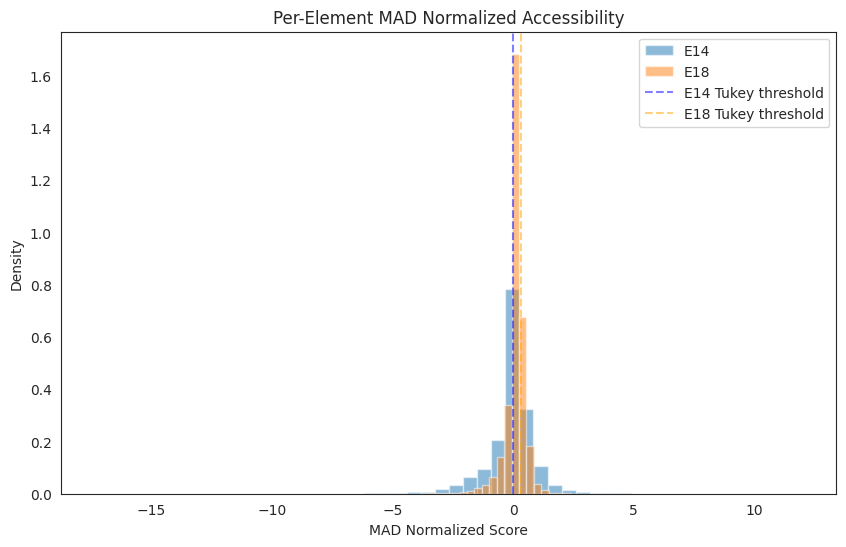


MAD NORMALIZATION COMPLETE
Added columns: E14_mean_mad_score, E18_mean_mad_score


,chr,start,end,gene,region_type,element_key_tuple,element_key,da_fold,D_E14,D_E18,E14_mean_mad_score,E18_mean_mad_score
0,chr1,3141476,3143476,4933401J01Rik,promoter,"(chr1, 3141476, 3143476, 4933401J01Rik)",chr1:3141476-3143476_4933401J01Rik,0.0,0,0,0.000000,0.000000
1,chr1,3170239,3172239,Gm26206,promoter,"(chr1, 3170239, 3172239, Gm26206)",chr1:3170239-3172239_Gm26206,0.0,0,0,0.000000,0.000000
2,chr1,3741721,3743721,Xkr4,promoter,"(chr1, 3741721, 3743721, Xkr4)",chr1:3741721-3743721_Xkr4,0.0,0,0,1.434714,0.721008
3,chr1,3320980,3322980,Gm18956,promoter,"(chr1, 3320980, 3322980, Gm18956)",chr1:3320980-3322980_Gm18956,0.0,0,0,0.000000,0.000000
4,chr1,3438772,3440772,Gm37180,promoter,"(chr1, 3438772, 3440772, Gm37180)",chr1:3438772-3440772_Gm37180,0.0,0,0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
257254,chr2,180171868,180172418,Ntsr1,enhancer,"(chr2, 180171868, 180172418, Ntsr1)",chr2:180171868-180172418_Ntsr1,0.0,0,0,-0.582175,0.262768
257255,chr12,72282307,72282427,2810055F11Rik,enhancer,"(chr12, 72282307, 72282427, 2810055F11Rik)",chr12:72282307-72282427_2810055F11Rik,0.0,0,0,0.000000,0.000000
257256,chr7,44667584,44668214,Dkkl1,enhancer,"(chr7, 44667584, 44668214, Dkkl1)",chr7:44667584-44668214_Dkkl1,0.0,0,0,0.000000,0.000000
257257,chr7,133378526,133378616,2700050L05Rik,enhancer,"(chr7, 133378526, 133378616, 2700050L05Rik)",chr7:133378526-133378616_2700050L05Rik,0.0,0,0,0.851094,0.401410


In [11]:
import matplotlib.pyplot as plt 
%matplotlib inline
# Load ATAC metadata
atac_meta = pd.read_csv(paths['atac_metadata'])

# Get ALL E14 and E18 samples for global distribution
all_e14_samples = atac_meta[atac_meta['Condition'] == 'E14']['SampleID'].tolist()
all_e18_samples = atac_meta[atac_meta['Condition'] == 'E18']['SampleID'].tolist()

# Get CD133 Cortex samples for Z-score calculation
cd133_e14_samples = atac_meta[
    (atac_meta['Condition'] == 'E14') & 
    (atac_meta['Factor'] == 'CD133') & 
    (atac_meta['Tissue'] == 'Cortex')
]['SampleID'].tolist()

cd133_e18_samples = atac_meta[
    (atac_meta['Condition'] == 'E18') & 
    (atac_meta['Factor'] == 'CD133') & 
    (atac_meta['Tissue'] == 'Cortex')
]['SampleID'].tolist()

print(f"Global - E14 samples: {len(all_e14_samples)}, E18 samples: {len(all_e18_samples)}")
print(f"CD133 Ctx - E14 samples: {len(cd133_e14_samples)}, E18 samples: {len(cd133_e18_samples)}")

# Get narrowPeak file paths
peak_dir = paths['atac_peak_dir']

# ALL samples
all_e14_peak_files = [os.path.join(peak_dir, f"{s}_peaks.narrowPeak") for s in all_e14_samples]
all_e18_peak_files = [os.path.join(peak_dir, f"{s}_peaks.narrowPeak") for s in all_e18_samples]
all_e14_peak_files = [f for f in all_e14_peak_files if os.path.exists(f)]
all_e18_peak_files = [f for f in all_e18_peak_files if os.path.exists(f)]

# CD133 Ctx samples
cd133_e14_peak_files = [os.path.join(peak_dir, f"{s}_peaks.narrowPeak") for s in cd133_e14_samples]
cd133_e18_peak_files = [os.path.join(peak_dir, f"{s}_peaks.narrowPeak") for s in cd133_e18_samples]
cd133_e14_peak_files = [f for f in cd133_e14_peak_files if os.path.exists(f)]
cd133_e18_peak_files = [f for f in cd133_e18_peak_files if os.path.exists(f)]

print(f"Global - E14 files: {len(all_e14_peak_files)}, E18 files: {len(all_e18_peak_files)}")
print(f"CD133 Ctx - E14 files: {len(cd133_e14_peak_files)}, E18 files: {len(cd133_e18_peak_files)}")
all_files = all_e14_peak_files + all_e18_peak_files

grn_builder.compute_mad_normalized_accessibility(atac_meta, peak_dir, 
                                            cd133_e14_samples, cd133_e18_samples,
                                            plot=True)



## 3.1. Add accessibility z-score and allow some more TFs

In [19]:
import matplotlib.pyplot as plt 
%matplotlib inline
grn_e14, grn_e18 = grn_builder.build_condition_grns(
    zscore_threshold_group1=0.78*3,  # E14-specific threshold
    zscore_threshold_group2=0.35*3   # E18-specific threshold
)


STEP 4: BUILD CONDITION-SPECIFIC GRNs (DA OR Z-SCORE)
E14 MAD score threshold: 2.34
E18 MAD score threshold: 1.0499999999999998

--------------------------------------------------------------------------------
Building E14 GRN
--------------------------------------------------------------------------------
E14 DE TFs with ChIP: 28
Regulatory elements for E14 DE genes: 3026

E14 Element Selection (OR logic):
  DA only: 15
  MAD score only: 29
  Both DA and MAD score: 0
  Total active elements: 44

E14 TF→gene pairs (ChIP + Active + DE): 464

--------------------------------------------------------------------------------
Building E18 GRN
--------------------------------------------------------------------------------
E18 DE TFs with ChIP: 52
Regulatory elements for E18 DE genes: 14394

E18 Element Selection (OR logic):
  DA only: 27
  MAD score only: 101
  Both DA and MAD score: 0
  Total active elements: 128

E18 TF→gene pairs (ChIP + Active + DE): 2552

FINAL GRN SUMMARY
E14 GRN: 275

## 3.2 Check GRN preliminary stats

In [23]:
# Check E14 GRN
print("Total edges:", len(grn_e14))
print("Unique TFs:", grn_e14['TF'].nunique())
print("Unique targets:", grn_e14['gene'].nunique())

# Check how many targets are also TFs (TF-TF edges)
tf_set = set(grn_builder.deseq_results[grn_builder.deseq_results['is_TF']]['symbol'].str.upper())
tf_tf_edges = grn_e14[grn_e14['gene'].str.upper().isin(tf_set)]

print(f"\nTF-TF edges: {len(tf_tf_edges)}")
print(f"TF→non-TF edges: {len(grn_e14) - len(tf_tf_edges)}")

if len(tf_tf_edges) > 0:
    print("\nSample TF-TF edges:")
    print(tf_tf_edges.head(10))

Total edges: 275
Unique TFs: 22
Unique targets: 38

TF-TF edges: 70
TF→non-TF edges: 205

Sample TF-TF edges:
       TF   gene
0   IKZF1  Bach2
1  PRDM13  Bach2
2   HMGA2  Bach2
3   SALL4  Bach2
4  BCL11B  Bach2
5   SMAD3  Bach2
6    E2F3  Bach2
7    HES1  Bach2
8   FOXP1  Bach2
9   BACH2  Bach2


## 3.2. Upset plots first


CREATING UPSET PLOT FOR E18

Set sizes:
  DE TFs (E18): 66
  ChIP TFs (all): 648
  DA-regulating TFs (E18): 527
  Total unique TFs: 686

Intersection counts:
  (False, True, False): 114 TFs
  (False, True, True): 506 TFs
  (True, False, False): 38 TFs
  (True, True, False): 7 TFs
  (True, True, True): 21 TFs

Saved to: upset_e18_actual_counts.png


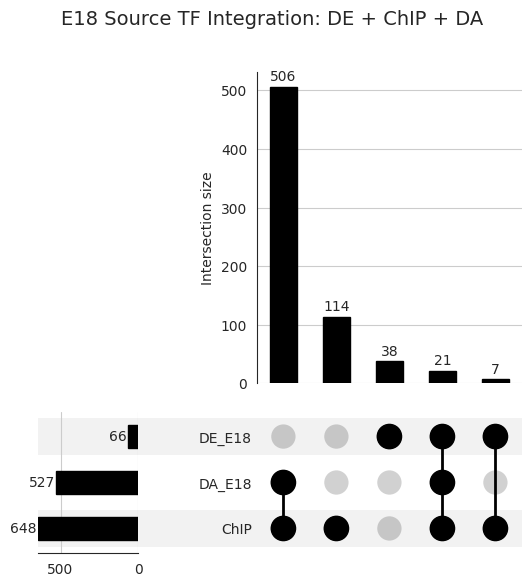


CREATING UPSET PLOT FOR E14

Set sizes:
  DE TFs (E14): 117
  ChIP TFs (all): 648
  DA-regulating TFs (E14): 581
  Total unique TFs: 713

Intersection counts:
  (False, True, False): 66 TFs
  (False, True, True): 530 TFs
  (True, False, False): 65 TFs
  (True, True, False): 1 TFs
  (True, True, True): 51 TFs

Saved to: upset_e14_actual_counts.png


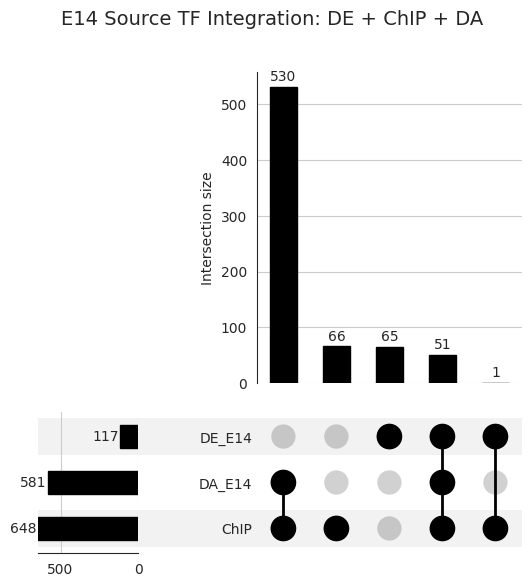

In [25]:
from upsetplot import UpSet

def create_grn_upset_plot(grn_builder, deseq_results, condition='E18', 
                          save_path=None, figsize=(12, 7)):
    """
    Create UpSet plot showing TF source integration (DE + ChIP + DA).
    """
    print(f"\n{'='*80}")
    print(f"CREATING UPSET PLOT FOR {condition}")
    print(f"{'='*80}")
    
    # 1. Get DE TFs for this condition
    de_tfs = set(deseq_results[
        (deseq_results['is_TF'] == True) & 
        (deseq_results['direction'] == condition) &
        (deseq_results['significant'] == True)
    ]['symbol'].str.upper())
    
    # 2. Get all TFs with ChIP binding
    chip_tfs = set(grn_builder.chip_overlap_df['TF'].unique())
    
    # 3. Get TFs that bind to DA regulatory elements in this condition
    da_col = f'D_{condition}'
    
    if da_col not in grn_builder.merged_regulatory.columns:
        raise ValueError(f"Column '{da_col}' not found in merged_regulatory. "
                        f"Available columns: {grn_builder.merged_regulatory.columns.tolist()}")
    
    da_regulating = set(grn_builder.chip_overlap_df[
        grn_builder.chip_overlap_df['element_key'].isin(
            grn_builder.merged_regulatory[grn_builder.merged_regulatory[da_col] == 1]['element_key']
        )
    ]['TF'].unique())
    
    # 4. Combine all TFs
    all_tfs = de_tfs.union(chip_tfs).union(da_regulating)
    
    print(f"\nSet sizes:")
    print(f"  DE TFs ({condition}): {len(de_tfs)}")
    print(f"  ChIP TFs (all): {len(chip_tfs)}")
    print(f"  DA-regulating TFs ({condition}): {len(da_regulating)}")
    print(f"  Total unique TFs: {len(all_tfs)}")
    
    # 5. Create membership dataframe
    membership = []
    for tf in all_tfs:
        membership.append({
            'TF': tf,
            f'DE_{condition}': tf in de_tfs,
            'ChIP': tf in chip_tfs,
            f'DA_{condition}': tf in da_regulating
        })
    
    df = pd.DataFrame(membership)
    
    # 6. Create UpSet data structure - EXACTLY like your working code
    upset_data = df.set_index([f'DE_{condition}', 'ChIP', f'DA_{condition}'])['TF']
    upset_counts = upset_data.groupby(level=[0, 1, 2]).count()
    
    print(f"\nIntersection counts:")
    for idx, count in upset_counts.items():
        print(f"  {idx}: {count} TFs")
    
    # 7. Plot
    fig = plt.figure(figsize=figsize)
    upset = UpSet(upset_counts, 
                  show_counts=True,
                  sort_by='cardinality',
                  element_size=50)
    upset.plot(fig=fig)
    plt.suptitle(f'{condition} Source TF Integration: DE + ChIP + DA', 
                 fontsize=14, y=0.98)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nSaved to: {save_path}")
    
    plt.show()
    
    # 8. Return results
    return {
        'upset_counts': upset_counts,
        'membership_df': df,
        'set_sizes': {
            'DE': len(de_tfs),
            'ChIP': len(chip_tfs),
            'DA': len(da_regulating),
            'Total': len(all_tfs)
        }
    }


# Usage - this should now work correctly
results_e18 = create_grn_upset_plot(
    grn_builder=grn_builder,
    deseq_results=nsc.deseq_results,
    condition='E18',
    save_path='upset_e18_actual_counts.png'
)

results_e14 = create_grn_upset_plot(
    grn_builder=grn_builder,
    deseq_results=nsc.deseq_results,
    condition='E14',
    save_path='upset_e14_actual_counts.png'
)

## 4.0 Network Analysis

In [27]:
import src.models.grn.network_analyzer as nxa
reload(nxa)

<module 'src.models.grn.network_analyzer' from '/mnt/scratch/users/adhal/CorticalNeuronFate/CellConversionNSC/src/models/grn/network_analyzer.py'>

## 4.1. First get TF-TF and Full networks

In [29]:
## TF 
tf_symbols = list(nsc.tf_symbols)
tf_symbols = [i.upper() for i in tf_symbols]

grn_e14['gene'] = [i.upper() for i in grn_e14['gene'].tolist()]
tf_tf_grn_e14 = grn_e14[(grn_e14['gene'].isin(tf_symbols)) & (grn_e14['TF'] != grn_e14['gene'])]

grn_e18['gene'] = [i.upper() for i in grn_e18['gene'].tolist()]
tf_tf_grn_e18 = grn_e18[(grn_e18['gene'].isin(tf_symbols)) & (grn_e18['TF'] != grn_e18['gene'])]


## 4.1.1 E14 full network


Network: 57 nodes, 275 edges

STRONGLY CONNECTED COMPONENTS (SCCs)
Total SCCs: 57
SCCs with feedback loops (size >= 2): 0

No feedback loops found - network is a DAG

Largest SCC: Size 1
Subnetwork: 57 nodes, 275 edges


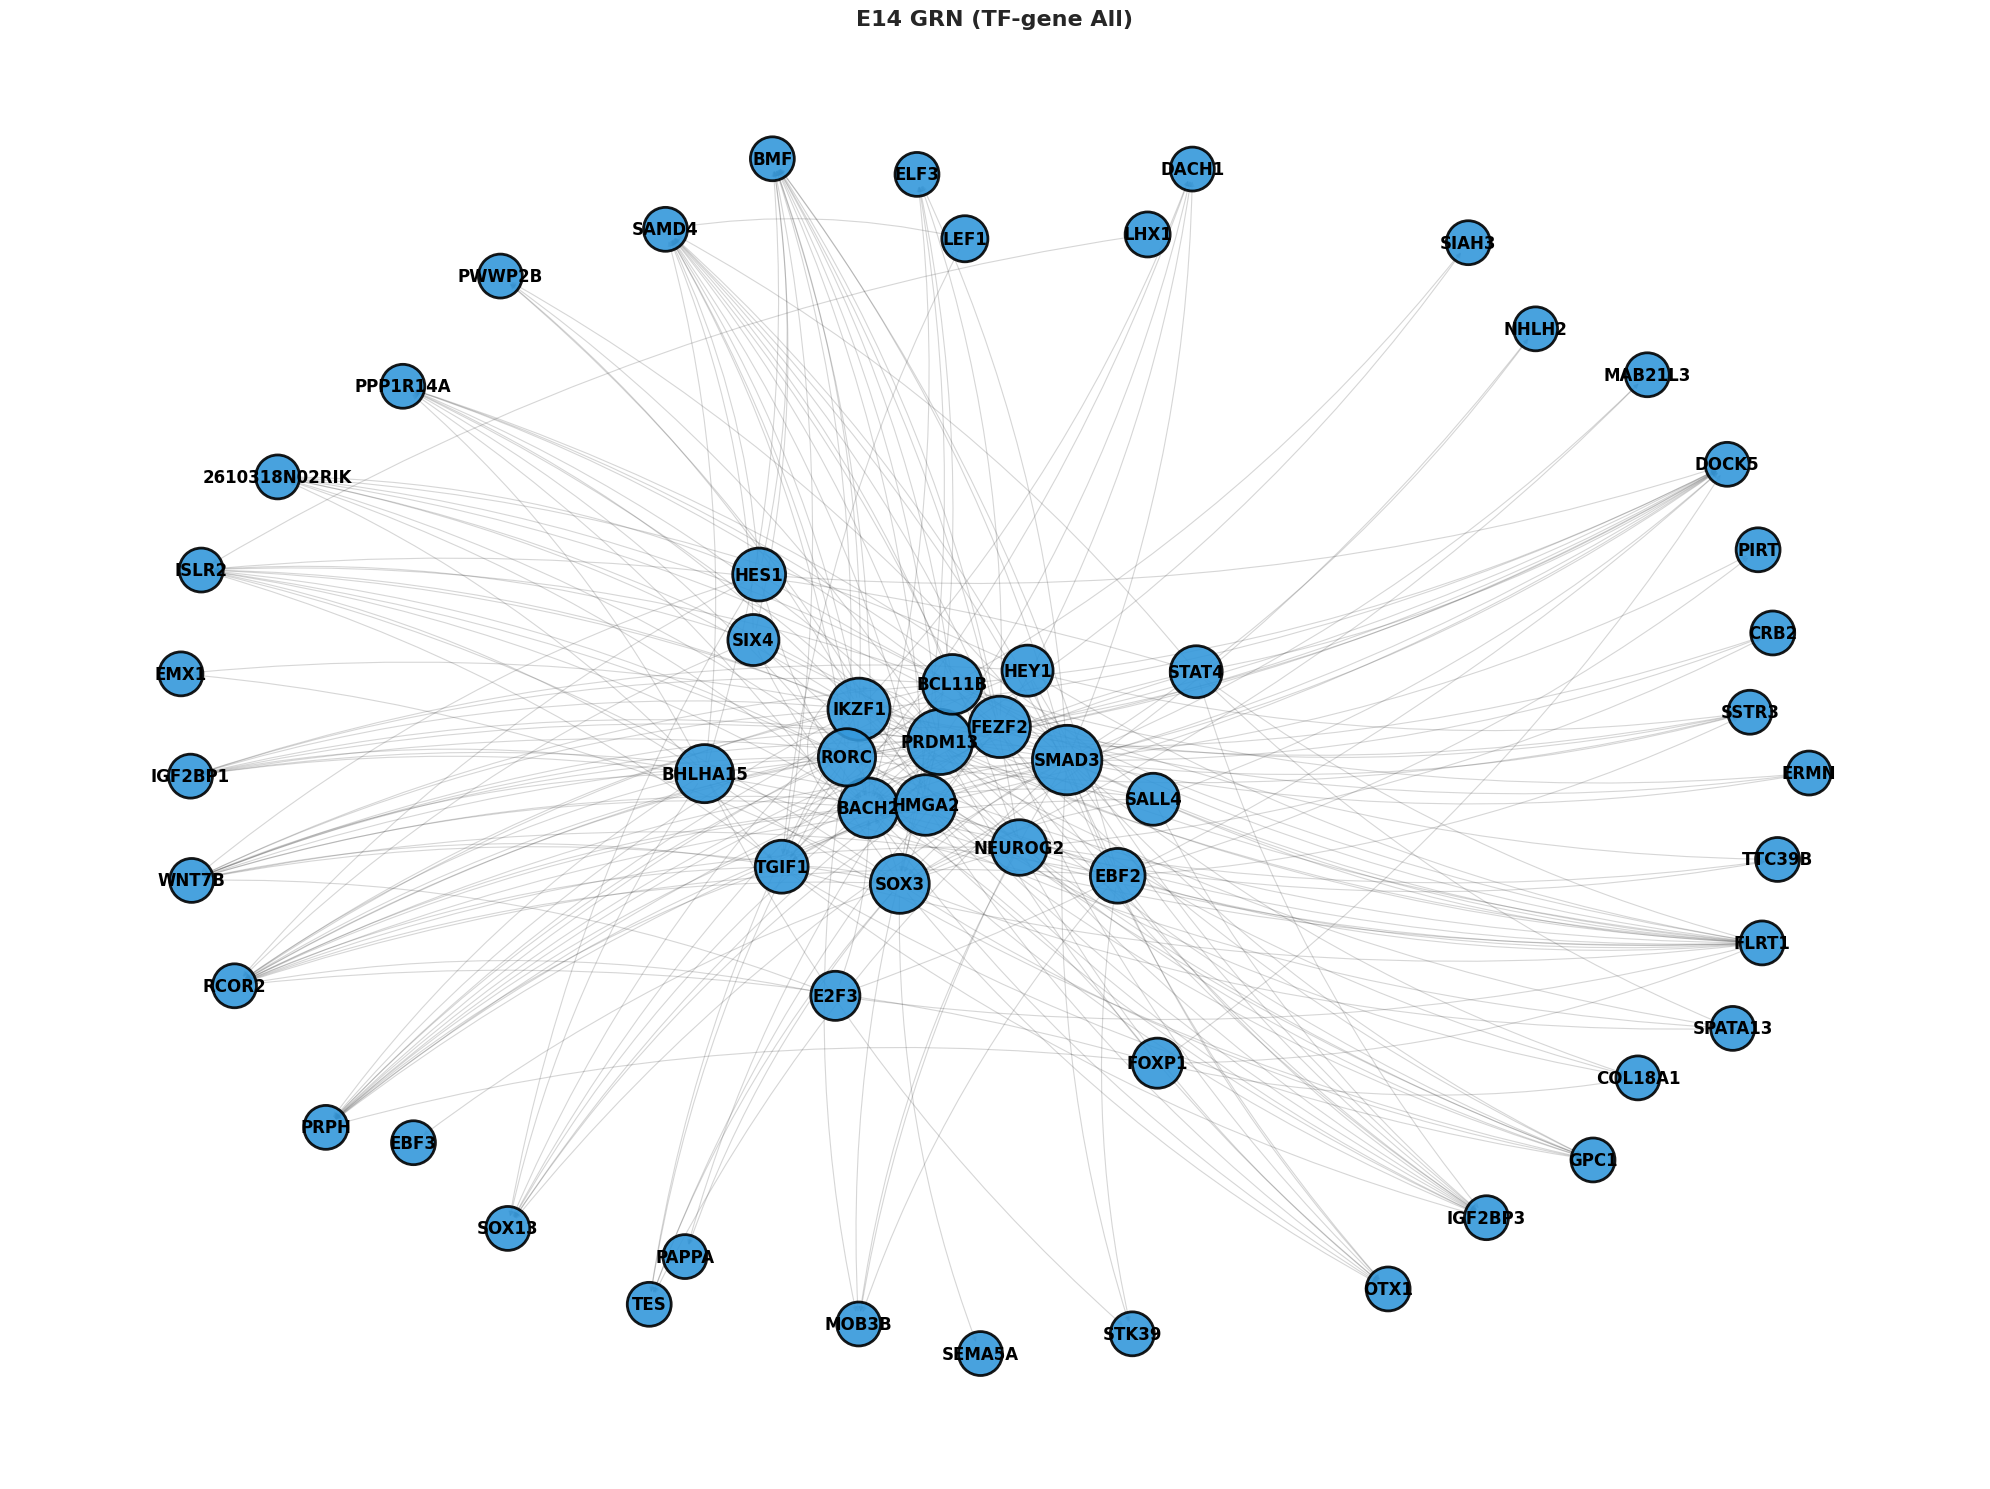

         out_degree  in_degree  reachability  pagerank  betweenness      katz
SMAD3            30          0            36  0.012895     0.000000  0.126104
PRDM13           24          0            33  0.012895     0.000000  0.126104
FEZF2            19          0            30  0.012895     0.000000  0.126104
SALL4             8          0            28  0.012895     0.000000  0.126104
SOX3             16          4            27  0.015664     0.009199  0.131148
IKZF1            20          0            23  0.012895     0.000000  0.126104
HMGA2            18          0            22  0.012895     0.000000  0.126104
EBF2             11          0            21  0.012895     0.000000  0.126104
BCL11B           17          0            20  0.012895     0.000000  0.126104
FOXP1             6          0            18  0.012895     0.000000  0.126104
SIX4              7          0            18  0.012895     0.000000  0.126104
HES1              9          0            17  0.012895     0.000

In [30]:
%matplotlib inline
# Initialize
analyzer = nxa.NetworkAnalyzer(
    grn_df=grn_e14, 
    tf_col='TF', 
    target_col='gene', 
    deseq_results=nsc.deseq_results
)

# Build graph
analyzer.build_graph()

# Compute stats
results = analyzer.compute_network_stats()

# Visualize
analyzer.visualize_network(
    title="E14 GRN (TF-gene All)", 
    network_score_col='reachability',
    top_k=50
)

# tget tf_tf network only 
tf_symbols = nsc.tf_symbols
tf_tf_e14 = analyzer.get_tf_tf_network(tf_symbols, grn_e14)
# Access results
print(results['tf_scores'].sort_values('reachability', ascending=False).head(20))

In [58]:
tf_tf_e14

,TF,gene,TF_is_patterning,target_is_patterning
0,IKZF1,BACH2,False,True
1,PRDM13,BACH2,True,True
2,HMGA2,BACH2,False,True
3,SALL4,BACH2,True,True
4,BCL11B,BACH2,False,True
...,...,...,...,...
268,SMAD3,SOX13,False,False
269,BCL11B,SOX13,False,False
270,BACH2,SOX13,True,False
271,FEZF2,SOX13,True,False


In [59]:
grn_e14

,TF,gene,TF_is_patterning,target_is_patterning
0,IKZF1,BACH2,False,True
1,PRDM13,BACH2,True,True
2,HMGA2,BACH2,False,True
3,SALL4,BACH2,True,True
4,BCL11B,BACH2,False,True
...,...,...,...,...
270,BACH2,SOX13,True,False
271,FEZF2,SOX13,True,False
272,BHLHA15,SOX13,True,False
273,SOX3,MAB21L3,False,False


## 4.1.2. E14 TF-TF


Network: 28 nodes, 69 edges

STRONGLY CONNECTED COMPONENTS (SCCs)
Total SCCs: 28
SCCs with feedback loops (size >= 2): 0

No feedback loops found - network is a DAG

Largest SCC: Size 1
Subnetwork: 28 nodes, 69 edges


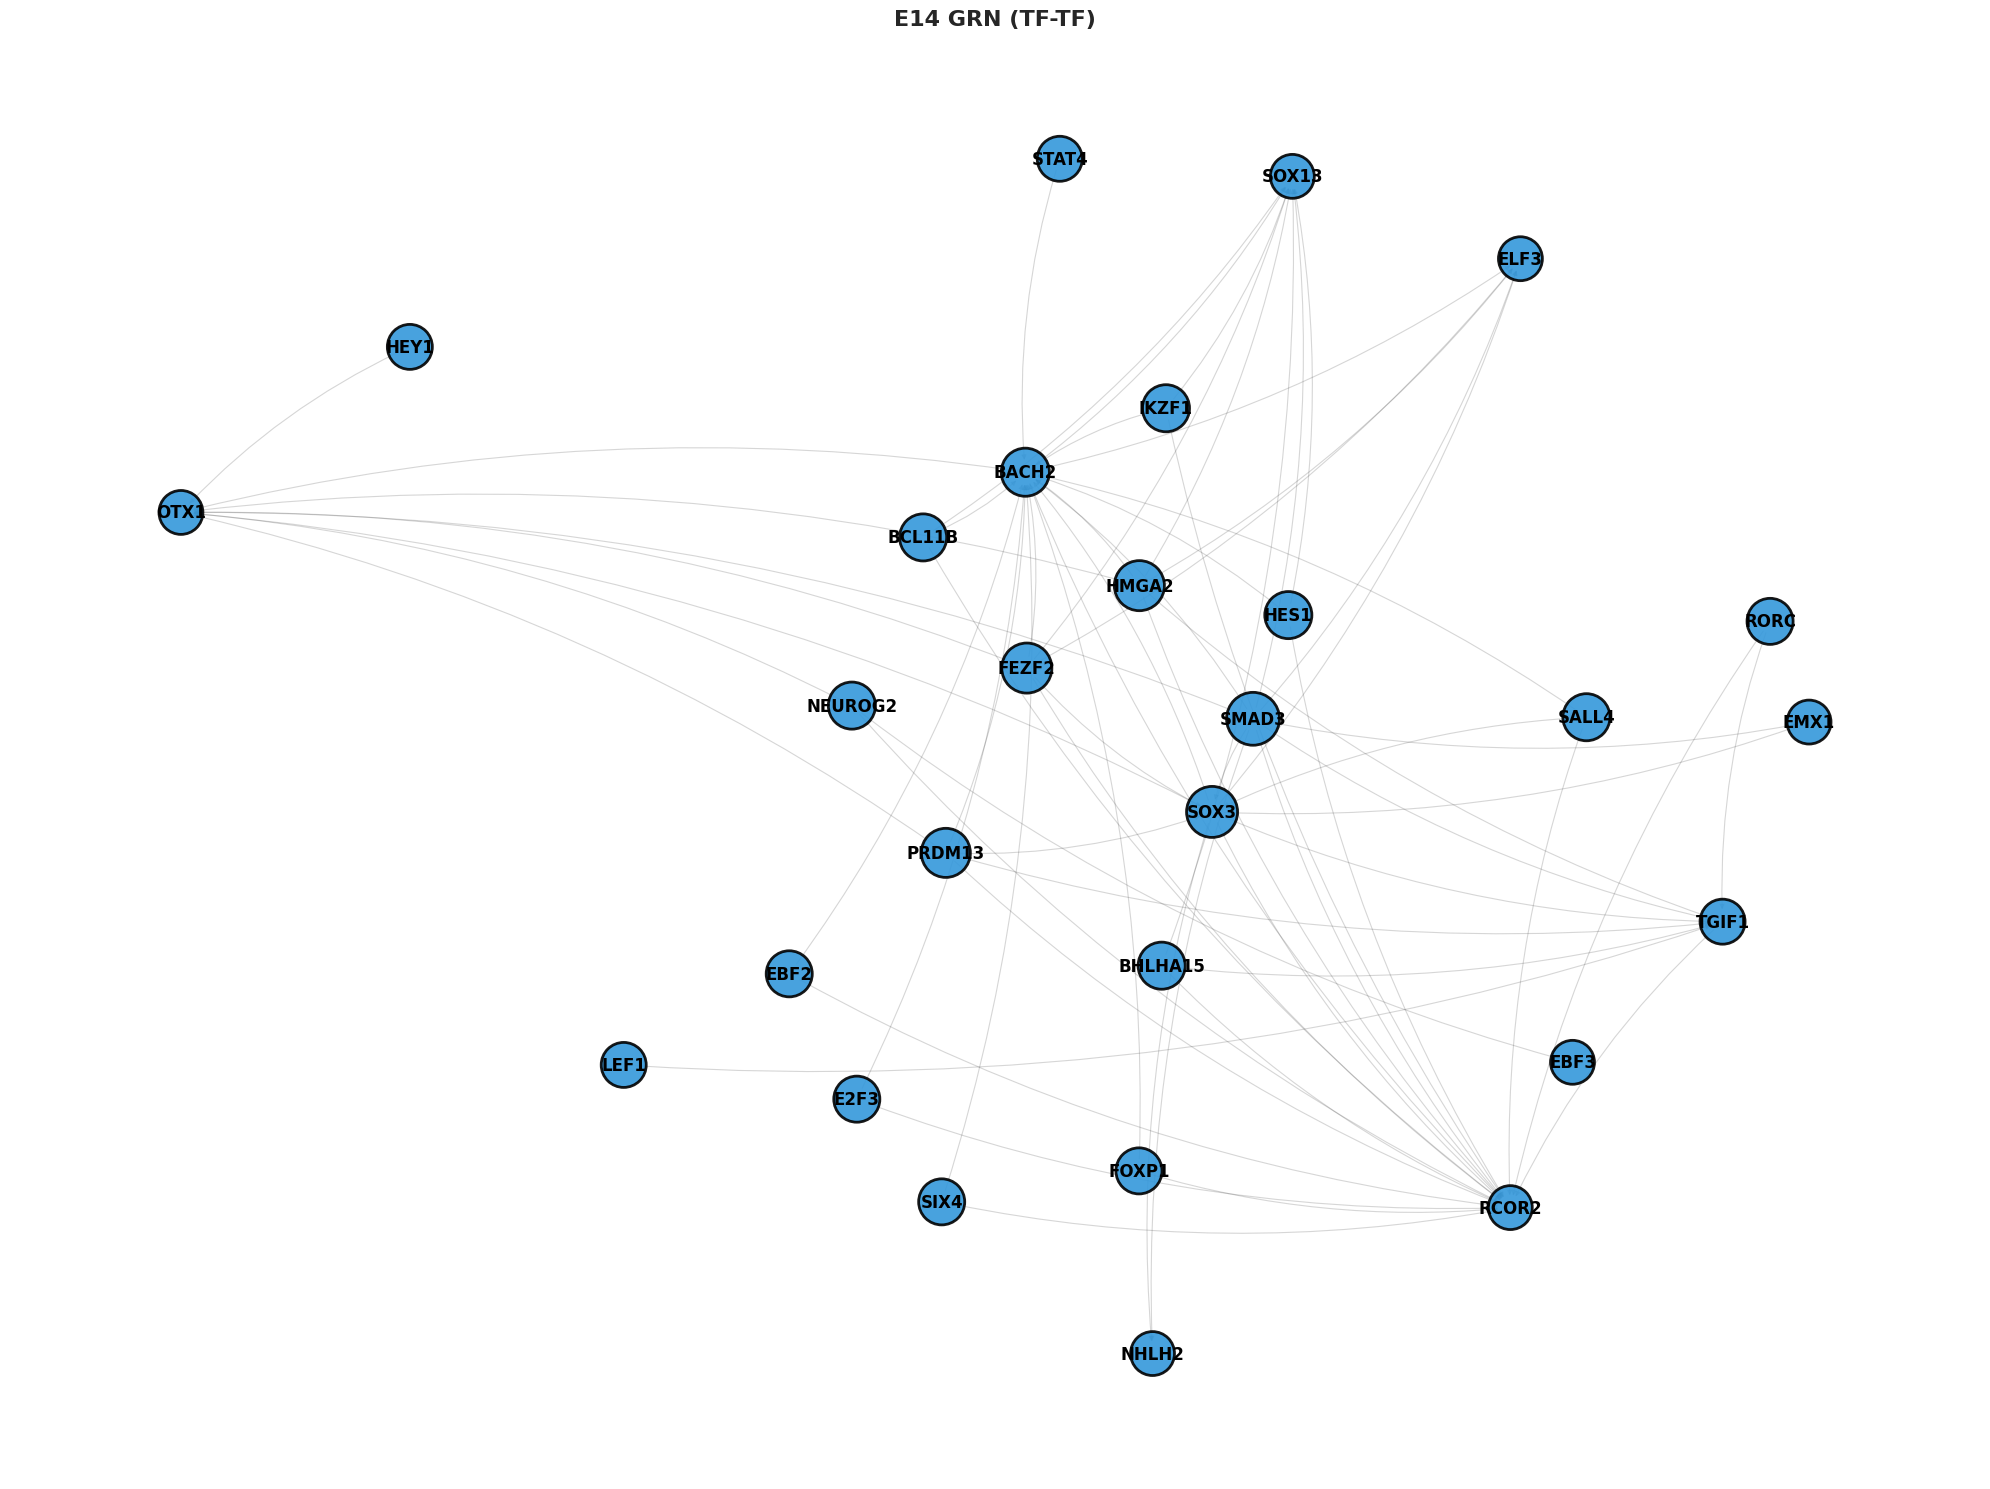

In [31]:
# Visualize
# Initialize
analyzer_tf_tf = nxa.NetworkAnalyzer(
    grn_df=tf_tf_e14, 
    tf_col='TF', 
    target_col='gene', 
    deseq_results=nsc.deseq_results
)

# Build graph
analyzer_tf_tf .build_graph()

# Compute stats
results_tf_tf = analyzer_tf_tf.compute_network_stats()

# Visualize
analyzer_tf_tf.visualize_network(
    title="E14 GRN (TF-TF)", 
    network_score_col='reachability',
    top_k=50
)


## 4.1.3. E18 network analysis


Network: 152 nodes, 1620 edges

STRONGLY CONNECTED COMPONENTS (SCCs)
Total SCCs: 152
SCCs with feedback loops (size >= 2): 0

No feedback loops found - network is a DAG

Largest SCC: Size 1
Subnetwork: 150 nodes, 1618 edges


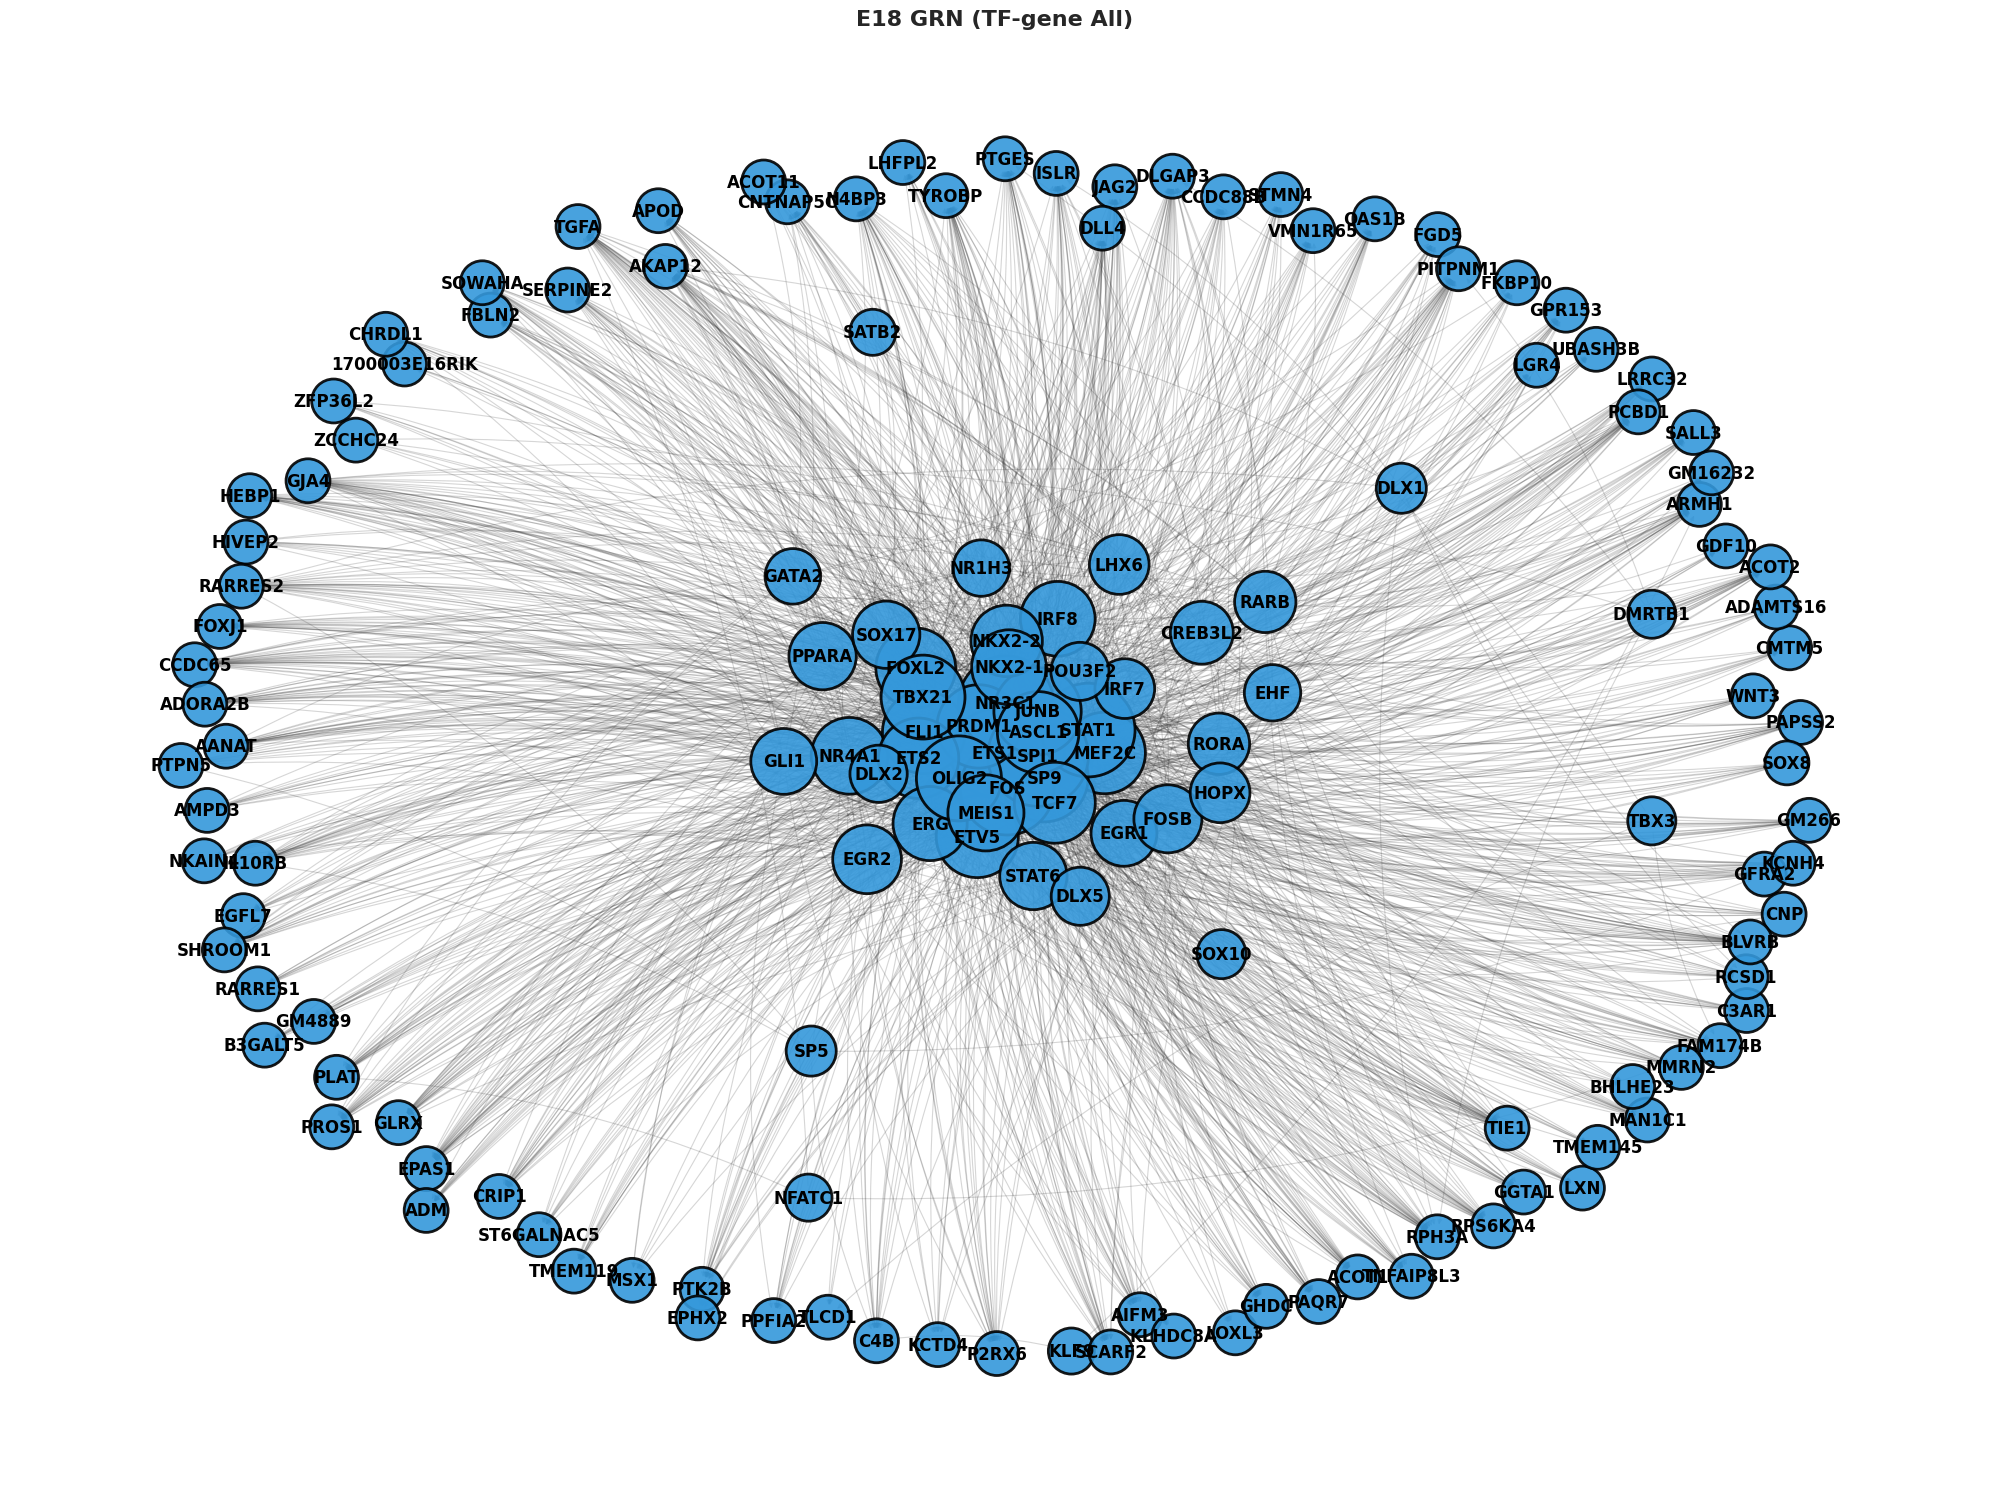

        out_degree  in_degree  reachability  pagerank  betweenness      katz
SPI1            85          0            90  0.005084          0.0  0.072965
SP9             60          0            86  0.005084          0.0  0.072965
STAT1           71          0            83  0.005084          0.0  0.072965
NR3C1           74          0            81  0.005084          0.0  0.072965
FOS             71          0            78  0.005084          0.0  0.072965
TBX21           53          0            77  0.005084          0.0  0.072965
ETS1            59          0            76  0.005084          0.0  0.072965
FLI1            51          0            76  0.005084          0.0  0.072965
OLIG2           55          0            76  0.005084          0.0  0.072965
FOXL2           46          0            75  0.005084          0.0  0.072965
ASCL1           49          0            75  0.005084          0.0  0.072965
PRDM1           52          0            73  0.005084          0.0  0.072965

In [32]:
%matplotlib inline
# Initialize
analyzer_e18 = nxa.NetworkAnalyzer(
    grn_df=grn_e18, 
    tf_col='TF', 
    target_col='gene', 
    deseq_results=nsc.deseq_results
)

# Build graph
analyzer_e18.build_graph()

# Compute stats
results_e18 = analyzer_e18.compute_network_stats()

# Visualize
analyzer_e18.visualize_network(
    title="E18 GRN (TF-gene All)", 
    network_score_col='reachability',
    top_k=50
)

# tget tf_tf network only 
tf_symbols = nsc.tf_symbols
tf_tf_e18 = analyzer_e18.get_tf_tf_network(tf_symbols, grn_e18)
# Access results
print(results_e18['tf_scores'].sort_values('reachability', ascending=False).head(20))

## 4.1.4. E18 TF-TF network


Network: 44 nodes, 88 edges

STRONGLY CONNECTED COMPONENTS (SCCs)
Total SCCs: 44
SCCs with feedback loops (size >= 2): 0

No feedback loops found - network is a DAG

Largest SCC: Size 1
Subnetwork: 44 nodes, 88 edges


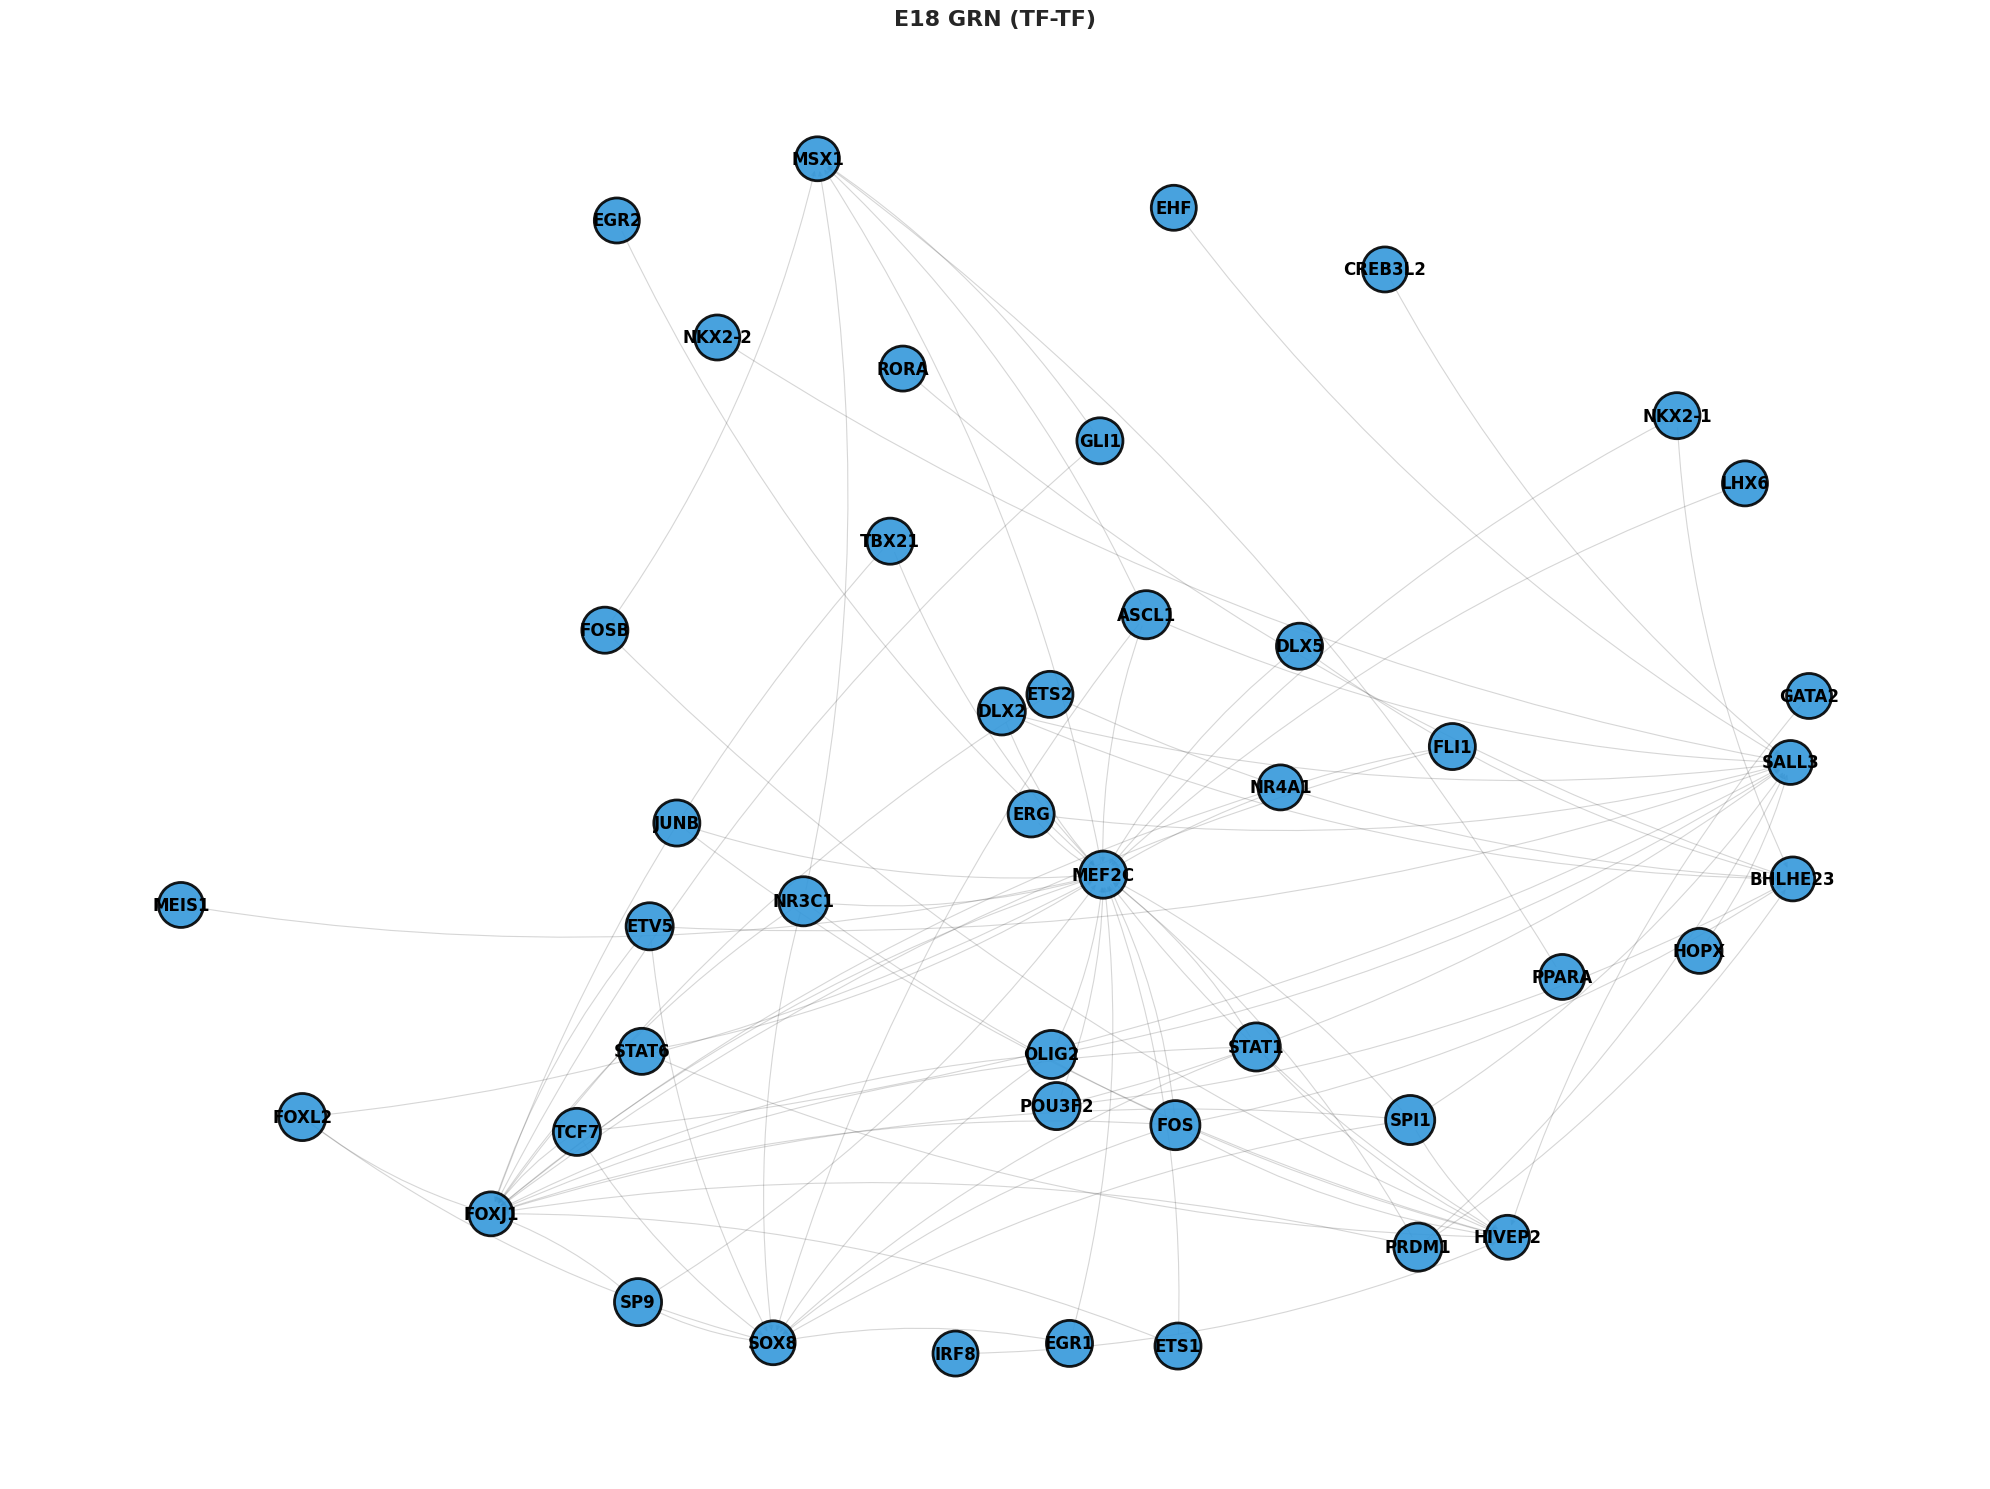

        out_degree  in_degree  reachability  pagerank  betweenness      katz
PRDM1            4          0             6  0.011928          0.0  0.147593
POU3F2           3          0             6  0.011928          0.0  0.147593
DLX2             3          0             6  0.011928          0.0  0.147593
FOS              5          0             6  0.011928          0.0  0.147593
SPI1             5          0             6  0.011928          0.0  0.147593
OLIG2            4          0             6  0.011928          0.0  0.147593
ASCL1            4          0             6  0.011928          0.0  0.147593
ERG              2          0             5  0.011928          0.0  0.147593
SP9              3          0             5  0.011928          0.0  0.147593
EGR1             2          0             5  0.011928          0.0  0.147593
NKX2-1           2          0             5  0.011928          0.0  0.147593
DLX5             2          0             5  0.011928          0.0  0.147593

In [33]:
%matplotlib inline
# Initialize
analyzer_e18_tf_tf = nxa.NetworkAnalyzer(
    grn_df=tf_tf_e18, 
    tf_col='TF', 
    target_col='gene', 
    deseq_results=nsc.deseq_results
)

# Build graph
analyzer_e18_tf_tf .build_graph()

# Compute stats
results_e18_tf_tf = analyzer_e18_tf_tf .compute_network_stats()

# Visualize
analyzer_e18_tf_tf .visualize_network(
    title="E18 GRN (TF-TF)", 
    network_score_col='reachability',
    top_k=50
)

# tget tf_tf network only 
tf_symbols = nsc.tf_symbols
tf_tf_e18 = analyzer_e18.get_tf_tf_network(tf_symbols, grn_e18)
# Access results
print(results_e18_tf_tf['tf_scores'].sort_values('reachability', ascending=False).head(20))

## 4.2. Testing the integration of patterning factors 


Network: 28 nodes, 69 edges

ANNOTATING PATTERNING FACTORS IN TF SCORES

Patterning factors in TF scores:
  Acting as regulators: 13
  Acting as targets: 6
  Acting as both: 2

  Patterning TFs acting as regulators: ['BACH2', 'BHLHA15', 'EBF2', 'FEZF2', 'HEY1', 'LEF1', 'NEUROG2', 'PRDM13', 'RORC', 'SALL4', 'SIX4', 'STAT4', 'TGIF1']
  Patterning TFs acting as targets: ['BACH2', 'EBF3', 'EMX1', 'NHLH2', 'OTX1', 'TGIF1']

STRONGLY CONNECTED COMPONENTS (SCCs)
Total SCCs: 28
SCCs with feedback loops (size >= 2): 0

No feedback loops found - network is a DAG

Largest SCC: Size 1

TF Scores with Patterning Annotations:
         out_degree  reachability  patterning_as_TF  patterning_as_target
IKZF1             3             5             False                 False
BACH2             4             4              True                  True
PRDM13            5             9              True                 False
HMGA2             6             6             False                 False
SALL4    

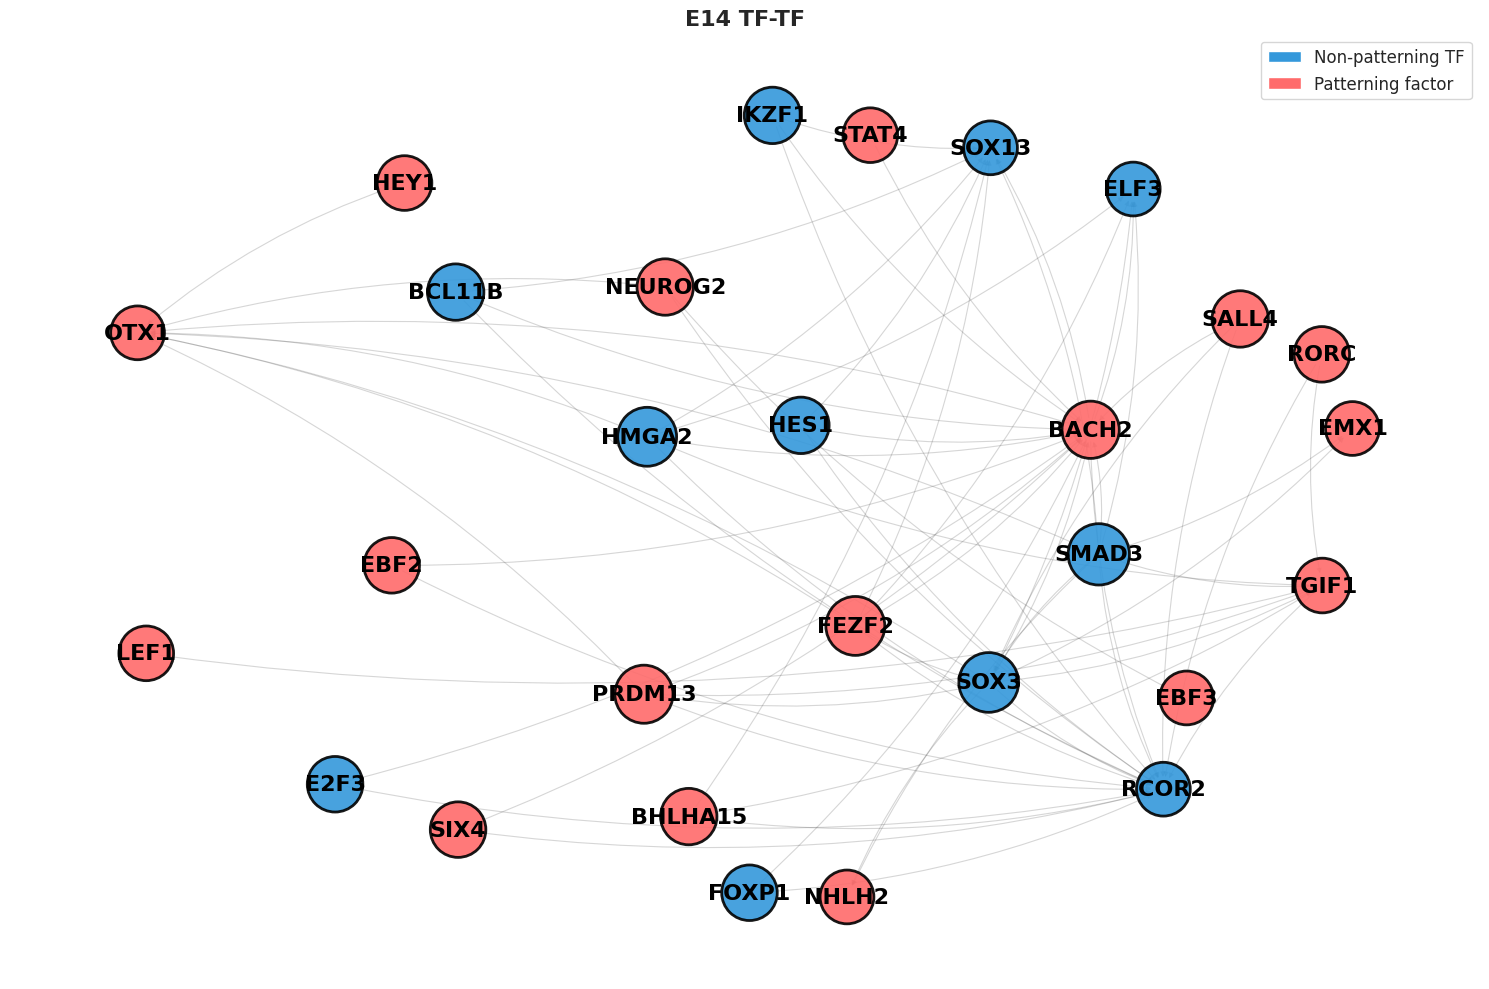

In [34]:
import networkx as nx
class NetworkAnalyzer2:
    def __init__(self, grn_df: pd.DataFrame, tf_col: str, target_col: str, 
                 deseq_results: pd.DataFrame, patterning_factors: list = None) -> None:
        """
        Initialize NetworkAnalyzer.
        
        Args:
            grn_df: GRN edge list
            tf_col: Column name for TFs
            target_col: Column name for targets
            deseq_results: DESeq results with TF annotations
            patterning_factors: Optional list of patterning factor names
        """
        self.grn_df = grn_df
        self.tf_col = tf_col 
        self.target_col = target_col 
        self.deseq_results = deseq_results
        self.patterning_factors = patterning_factors
        self.G = None 
        self.scores = None 
        
    def build_graph(self):
        """Build directed graph from GRN."""
        if self.G is None:              
            self.G = nx.DiGraph()
            self.G.add_edges_from(
                self.grn_df[[self.tf_col, self.target_col]].itertuples(index=False, name=None)
            )
        return self.G
        
    def compute_network_stats(self):
        """Compute network centrality metrics."""
        if self.G is None:
            self.build_graph()
            
        print(f"\nNetwork: {self.G.number_of_nodes()} nodes, {self.G.number_of_edges()} edges")
        
        # Compute metrics
        out_deg = dict(self.G.out_degree())
        in_deg = dict(self.G.in_degree())
        reachability = {n: len(nx.descendants(self.G, n)) for n in self.G.nodes()}
        pagerank = nx.pagerank(self.G) if self.G.number_of_edges() > 0 else {n: 0 for n in self.G.nodes()}
        betweenness = nx.betweenness_centrality(self.G, normalized=True)
        
        # Try higher alpha for Katz
        try:
            katz = nx.katz_centrality(self.G, alpha=0.1, beta=1.0, max_iter=1000)
        except nx.PowerIterationFailedConvergence:
            print("  Warning: Katz with alpha=0.1 didn't converge, trying alpha=0.05")
            try:
                katz = nx.katz_centrality(self.G, alpha=0.05, beta=1.0, max_iter=1000)
            except:
                print("  Warning: Katz failed, using zeros")
                katz = {n: 0 for n in self.G.nodes()}
        
        self.scores = pd.DataFrame({
            "out_degree": out_deg,
            "in_degree": in_deg,
            "reachability": reachability,
            "pagerank": pagerank,
            "betweenness": betweenness,
            "katz": katz
        }).fillna(0)
        
        # Get TF set (case-insensitive matching)
        tf_symbols_upper = set(self.deseq_results[self.deseq_results['is_TF']]['symbol'].str.upper())
        
        # Filter to TFs - match nodes case-insensitively
        tf_scores = self.scores[self.scores.index.str.upper().isin(tf_symbols_upper)].copy()
        
        # ===================================================================
        # INTEGRATE PATTERNING FACTOR ANNOTATION
        # ===================================================================
        if self.patterning_factors is not None:
            print("\n" + "="*80)
            print("ANNOTATING PATTERNING FACTORS IN TF SCORES")
            print("="*80)
            
            patterning_set = set([pf.upper() for pf in self.patterning_factors])
            
            # Check if each TF appears as a TF (regulator) in patterning edges
            tf_as_regulator = set(
                self.grn_df[self.grn_df[self.tf_col].str.upper().isin(patterning_set)][self.tf_col].str.upper()
            )
            
            # Check if each TF appears as a target in patterning edges
            tf_as_target = set(
                self.grn_df[self.grn_df[self.target_col].str.upper().isin(patterning_set)][self.target_col].str.upper()
            )
            
            # Annotate tf_scores
            tf_scores['patterning_as_TF'] = tf_scores.index.str.upper().isin(tf_as_regulator)
            tf_scores['patterning_as_target'] = tf_scores.index.str.upper().isin(tf_as_target)
            
            # Summary statistics
            n_tf_regulators = tf_scores['patterning_as_TF'].sum()
            n_tf_targets = tf_scores['patterning_as_target'].sum()
            n_both = (tf_scores['patterning_as_TF'] & tf_scores['patterning_as_target']).sum()
            
            print(f"\nPatterning factors in TF scores:")
            print(f"  Acting as regulators: {n_tf_regulators}")
            print(f"  Acting as targets: {n_tf_targets}")
            print(f"  Acting as both: {n_both}")
            
            # Show which patterning factors are present
            found_as_tf = sorted(tf_scores[tf_scores['patterning_as_TF']].index.tolist())
            found_as_target = sorted(tf_scores[tf_scores['patterning_as_target']].index.tolist())
            
            if found_as_tf:
                print(f"\n  Patterning TFs acting as regulators: {found_as_tf}")
            if found_as_target:
                print(f"  Patterning TFs acting as targets: {found_as_target}")
            
            print("="*80)
        
        # SCC Analysis
        print("\n" + "="*80)
        print("STRONGLY CONNECTED COMPONENTS (SCCs)")
        print("="*80)
        
        sccs = list(nx.strongly_connected_components(self.G))
        print(f"Total SCCs: {len(sccs)}")
        
        sccs_feedback = [scc for scc in sccs if len(scc) >= 2]
        print(f"SCCs with feedback loops (size >= 2): {len(sccs_feedback)}")
        
        if len(sccs_feedback) > 0:
            print("\nFeedback loop SCCs:")
            for i, scc in enumerate(sorted(sccs_feedback, key=len, reverse=True), 1):
                print(f"  SCC {i}: Size {len(scc)}: {sorted(list(scc))}")
        else:
            print("\nNo feedback loops found - network is a DAG")
        
        largest_scc = max(sccs, key=len)
        print(f"\nLargest SCC: Size {len(largest_scc)}")
        if len(largest_scc) >= 2:
            print(f"  Members: {sorted(list(largest_scc))}")
            
        return {
            'network_scores': self.scores, 
            'tf_scores': tf_scores, 
            'largest_scc': largest_scc, 
            'all_sccs': sccs
        }
        
    def visualize_network(self, title: str, network_score_col: str = 'reachability', 
                         top_k: int = 50, highlight_patterning: bool = False):
        """
        Visualize top regulators and their descendants.
        
        Args:
            title: Plot title
            network_score_col: Column to sort by for selecting top nodes
            top_k: Number of top nodes to include
            highlight_patterning: If True, color patterning factors differently
        """
        if self.scores is None:
            print("Please run compute_network_stats() first!")
            return
            
        # Get top master regulators
        top_mrs = self.scores.sort_values(network_score_col, ascending=False).head(top_k).index
        
        nodes = set(top_mrs)
        for tf in top_mrs:
            nodes |= nx.descendants(self.G, tf)
        
        H = self.G.subgraph(nodes).copy()
        
        print(f"Subnetwork: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
        
        # Layout
        plt.figure(figsize=(15, 10))
        pos = nx.spring_layout(H, k=3, iterations=100, seed=42)
        
        # Node sizes based on degree
        out_deg = dict(self.G.out_degree())
        node_sizes = [1500 + out_deg.get(node, 0) * 50 for node in H.nodes()]
        
        # Node colors
        if highlight_patterning and self.patterning_factors is not None:
            patterning_set = set([pf.upper() for pf in self.patterning_factors])
            node_colors = [
                '#FF6B6B' if node.upper() in patterning_set else '#3498db'  # Red for patterning, blue for others
                for node in H.nodes()
            ]
        else:
            node_colors = '#3498db'
        
        # Draw edges
        nx.draw_networkx_edges(
            H, pos,
            edge_color='#333333',
            alpha=0.2,
            arrows=True,
            arrowsize=7.5,
            width=0.8,
            connectionstyle='arc3,rad=0.1'
        )
        
        # Draw nodes
        nx.draw_networkx_nodes(
            H, pos,
            node_color=node_colors,
            node_size=node_sizes,
            alpha=0.9,
            edgecolors='black',
            linewidths=2
        )
        
        # Draw labels
        nx.draw_networkx_labels(
            H, pos,
            font_size=16,
            font_weight='bold',
            font_color='black'
        )
        
        plt.title(title, fontsize=16, fontweight='bold')
        
        # Add legend if highlighting patterning factors
        if highlight_patterning and self.patterning_factors is not None:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='#3498db', label='Non-patterning TF'),
                Patch(facecolor='#FF6B6B', label='Patterning factor')
            ]
            plt.legend(handles=legend_elements, loc='upper right', fontsize=12)
        
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# ============================================================================
# USAGE
# ============================================================================

# Define patterning factors
e14_ctx_lge_deseq = pd.read_csv('/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/results/cd133_e14_ctx_lge_grn/deseq_temporal_cd133.csv')
patterning_factors = e14_ctx_lge_deseq[(e14_ctx_lge_deseq['is_TF']) & (e14_ctx_lge_deseq['significant'])]['symbol'].tolist()

# Initialize analyzer WITH patterning factors
analyzer2 = NetworkAnalyzer2(
    grn_df=tf_tf_e14,  # or grn_e14_clean if you want to exclude patterning edges
    tf_col='TF', 
    target_col='gene', 
    deseq_results=nsc.deseq_results,
    patterning_factors=patterning_factors  # NEW parameter
)

# Compute stats (will now include patterning annotations)
results2 = analyzer2.compute_network_stats()

# Access TF scores with patterning annotations
tf_scores2 = results2['tf_scores']
print("\nTF Scores with Patterning Annotations:")
print(tf_scores2[['out_degree', 'reachability', 'patterning_as_TF', 'patterning_as_target']].head(20))

# Filter non-patterning master regulators
non_patterning_mrs = tf_scores2[
    ~tf_scores2['patterning_as_TF'] & ~tf_scores2['patterning_as_target']
].sort_values('reachability', ascending=False)

print("\nTop non-patterning master regulators:")
print(non_patterning_mrs.head(10))

# Visualize with patterning factors highlighted
analyzer2.visualize_network(
    title="E14 TF-TF",
    network_score_col='reachability',
    top_k=100,
    highlight_patterning=True  # Color patterning factors red
)

In [89]:
non_patterning_mrs

,out_degree,in_degree,reachability,pagerank,betweenness,katz,patterning_as_TF,patterning_as_target
SMAD3,9,0,9,0.019212,0.000000,0.137194,False,False
SOX3,7,4,8,0.032458,0.013533,0.192071,False,False
HMGA2,6,0,6,0.019212,0.000000,0.137194,False,False
BCL11B,3,0,5,0.019212,0.000000,0.137194,False,False
IKZF1,3,0,5,0.019212,0.000000,0.137194,False,False
HES1,3,0,5,0.019212,0.000000,0.137194,False,False
E2F3,2,0,5,0.019212,0.000000,0.137194,False,False
FOXP1,2,0,5,0.019212,0.000000,0.137194,False,False
RCOR2,0,18,0,0.181115,0.000000,0.419538,False,False
ELF3,0,5,0,0.052604,0.000000,0.231034,False,False



Network: 44 nodes, 88 edges

ANNOTATING PATTERNING FACTORS IN TF SCORES

Patterning factors in TF scores:
  Acting as regulators: 17
  Acting as targets: 5
  Acting as both: 1

  Patterning TFs acting as regulators: ['ASCL1', 'DLX2', 'DLX5', 'EGR2', 'ETS1', 'ETS2', 'FOSB', 'GLI1', 'HOPX', 'IRF8', 'LHX6', 'MEF2C', 'MEIS1', 'NKX2-1', 'OLIG2', 'SP9', 'TBX21']
  Patterning TFs acting as targets: ['BHLHE23', 'HIVEP2', 'MEF2C', 'SALL3', 'SOX8']

STRONGLY CONNECTED COMPONENTS (SCCs)
Total SCCs: 44
SCCs with feedback loops (size >= 2): 0

No feedback loops found - network is a DAG

Largest SCC: Size 1

TF Scores with Patterning Annotations:
         out_degree  reachability  patterning_as_TF  patterning_as_target
EHF               1             1             False                 False
SALL3             0             0             False                  True
POU3F2            3             6             False                 False
DLX2              3             6              True           

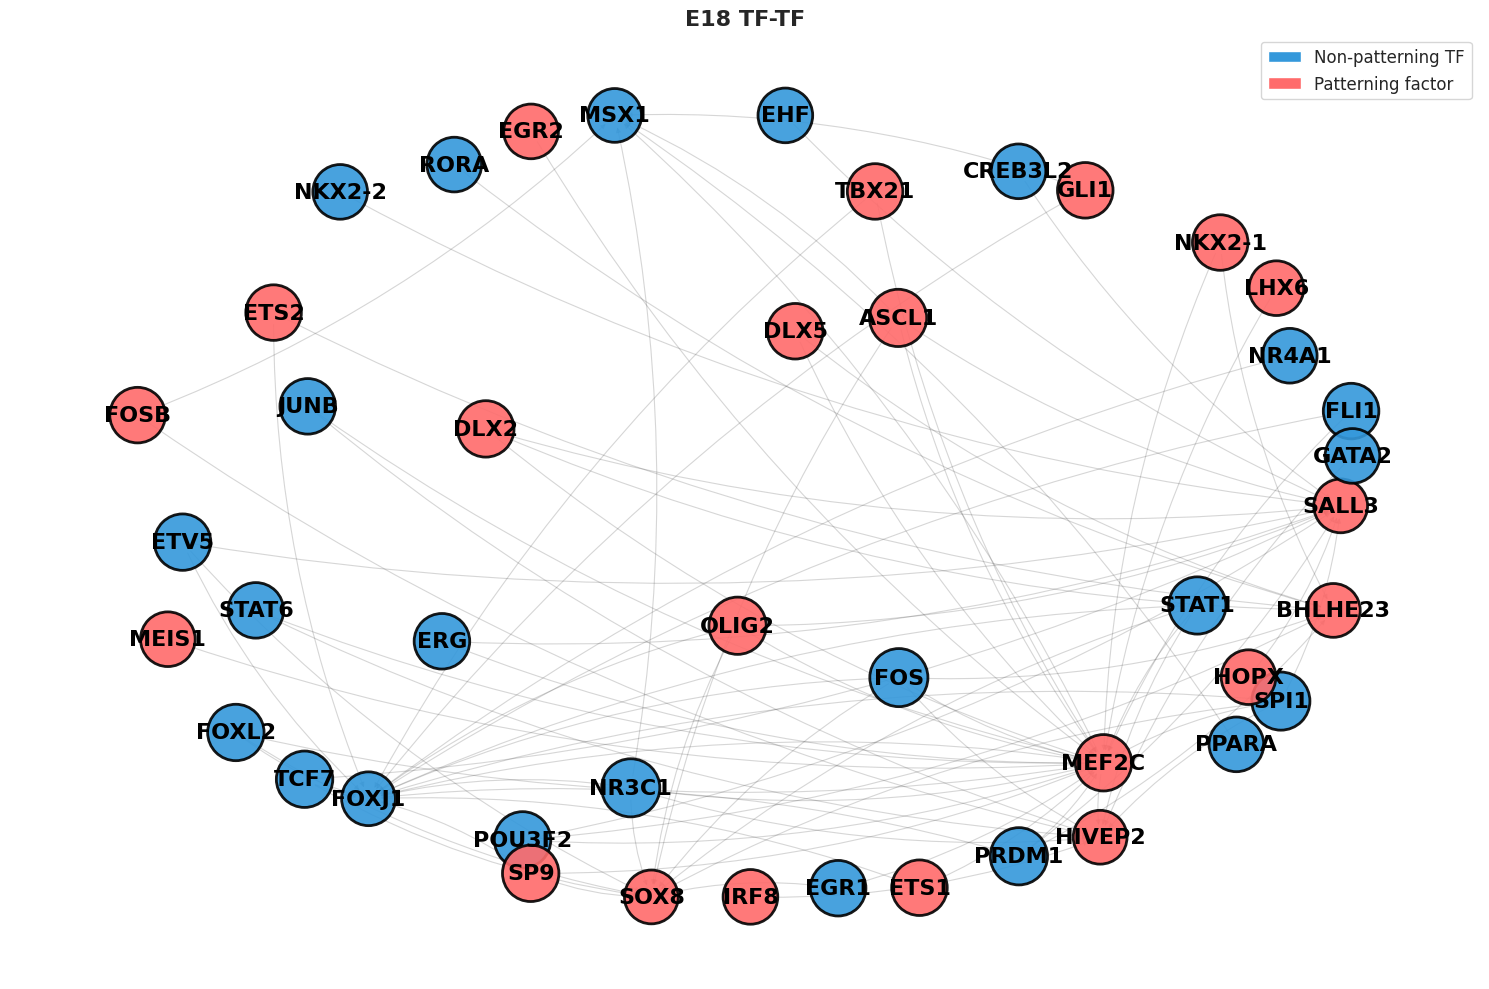

In [91]:
# ============================================================================
# USAGE
# ============================================================================

# Define patterning factors
e14_ctx_lge_deseq = pd.read_csv('/mnt/lscratch/users/adhal/CorticalNeuronFate/CellConversionNSC/results/cd133_e14_ctx_lge_grn/deseq_temporal_cd133.csv')
patterning_factors = e14_ctx_lge_deseq[(e14_ctx_lge_deseq['is_TF']) & (e14_ctx_lge_deseq['significant'])]['symbol'].tolist()

# Initialize analyzer WITH patterning factors
analyzer2 = NetworkAnalyzer2(
    grn_df=tf_tf_e18,  # or grn_e14_clean if you want to exclude patterning edges
    tf_col='TF', 
    target_col='gene', 
    deseq_results=nsc.deseq_results,
    patterning_factors=patterning_factors  # NEW parameter
)

# Compute stats (will now include patterning annotations)
results2 = analyzer2.compute_network_stats()

# Access TF scores with patterning annotations
tf_scores2 = results2['tf_scores']
print("\nTF Scores with Patterning Annotations:")
print(tf_scores2[['out_degree', 'reachability', 'patterning_as_TF', 'patterning_as_target']].head(20))

# Filter non-patterning master regulators
non_patterning_mrs = tf_scores2[
    ~tf_scores2['patterning_as_TF'] & ~tf_scores2['patterning_as_target']
].sort_values('reachability', ascending=False)

print("\nTop non-patterning master regulators:")
print(non_patterning_mrs.head(10))

# Visualize with patterning factors highlighted
analyzer2.visualize_network(
    title="E18 TF-TF",
    network_score_col='reachability',
    top_k=100,
    highlight_patterning=True  # Color patterning factors red
)